# Μοντελοποίηση της Ικανοποίησης και της Πιστότητας Πελατών με ένα Μοντέλο Δομικών Εξισώσεων (PROC CALIS)

## Σύνοψη για Στελέχη

Αυτό το σημειωματάριο προσαρμόζει ένα μοντέλο δομικών εξισώσεων (SEM) για έναν λιανοπωλητή καταναλωτικών αγαθών, συνδέοντας δύο λανθάνοντες παράγοντες — την αντιλαμβανόμενη ποιότητα υπηρεσίας και την αντιλαμβανόμενη αξία — με τη λανθάνουσα **ικανοποίηση** του πελάτη, και με τη σειρά της με τη λανθάνουσα **πιστότητα**. Χρησιμοποιώντας το `PROC CALIS` με τη γλώσσα μοντελοποίησης `LINEQS` (Bentler-Weeks), εκτιμά ταυτόχρονα το μοντέλο μέτρησης για κάθε κατασκεύασμα (construct) και τις δομικές διαδρομές μεταξύ τους, διορθώνοντας τις δομικές εκτιμήσεις για το σφάλμα μέτρησης.

Σε μια έρευνα 100 ερωτηθέντων το μοντέλο προσαρμόζεται καλά: chi-square = 50.81 με 49 βαθμούς ελευθερίας (p = 0.40), RMSEA = 0.019, CFI = 0.999, TLI = 0.998. Οι δομικές διαδρομές που ανακτήθηκαν από τα δεδομένα είναι **ικανοποίηση επί ποιότητας υπηρεσίας = 0.51** και **επί αξίας = 0.26**, και **πιστότητα επί ικανοποίησης = 0.80** με μια μικρή άμεση **πιστότητα επί αξίας = 0.15**. Διαβάζοντάς τα μαζί, το μεγαλύτερο μέρος της επίδρασης της αξίας στην πιστότητα ταξιδεύει *μέσω* της ικανοποίησης (έμμεση επίδραση 0.26 × 0.80 = 0.21, έναντι άμεσης επίδρασης 0.15), και η ποιότητα υπηρεσίας φτάνει στην πιστότητα σχεδόν εξ ολοκλήρου μέσω της ικανοποίησης (0.51 × 0.80 = 0.41). Το πρακτικό μήνυμα: η ικανοποίηση είναι ο κυρίαρχος μοχλός για την πιστότητα, και η ποιότητα υπηρεσίας είναι ο πιο αποδοτικός τρόπος για να αυξηθεί η ικανοποίηση εξαρχής.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται ενσωματωμένα (inline) στο πρώτο βήμα `DATA` (χωρίς εξωτερικά αρχεία). Ένα λανθάνον "αληθινό" ταξίδι ικανοποίησης προσομοιώνεται για κάθε ερωτηθέντα της έρευνας, και στη συνέχεια κάθε κατασκεύασμα παρατηρείται μέσω τριών θορυβωδών δεικτών τύπου Likert.

| Σύνολο δεδομένων | Γραμμές | Μεταβλητή | Ρόλος | Περιγραφή |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | Αναγνωριστικό | Αναγνωριστικό ερωτηθέντα |
| | | `q1`–`q3` | Δείκτες | Στοιχεία ποιότητας υπηρεσίας (λανθάνον ServQual) |
| | | `v1`–`v3` | Δείκτες | Στοιχεία αντιλαμβανόμενης αξίας (λανθάνον Value) |
| | | `s1`–`s3` | Δείκτες | Στοιχεία ικανοποίησης (λανθάνον Satis) |
| | | `l1`–`l3` | Δείκτες | Στοιχεία πιστότητας (λανθάνον Loyal) |

Οι δείκτες είναι συνεχείς τυποποιημένες βαθμολογίες (κεντραρισμένες ~0) που κατασκευάζονται ως `loading * latent + Normal noise`, ώστε οι παράμετροι μέτρησης και δομής που ανακτώνται από το `PROC CALIS` να είναι καλά προσδιορισμένες. Τα ServQual και Value είναι συσχετισμένα εξωγενή λανθάνοντα· το Satis παλινδρομείται και στα δύο, και το Loyal παλινδρομείται στο Satis με μια μικρότερη άμεση διαδρομή από το Value, κάτι που μας επιτρέπει να διαχωρίσουμε το έμμεσο κανάλι (μέσω της ικανοποίησης) από το άμεσο.

# Ικανοποίηση Πελατών → Πιστότητα: Ένα Μοντέλο Δομικών Εξισώσεων

Ένας λιανοπωλητής καταναλωτικών αγαθών διεξάγει μια έρευνα μετά την αγορά για να κατανοήσει τι οδηγεί στην επαναλαμβανόμενη πελατεία. Η θεωρία εργασίας είναι μια κλασική αλυσίδα ικανοποίησης–πιστότητας:

- Η **ποιότητα υπηρεσίας** και η **αντιλαμβανόμενη αξία** είναι δύο ξεχωριστά πράγματα που βιώνουν οι πελάτες.
- Και τα δύο τροφοδοτούν τη συνολική **ικανοποίηση**.
- Η ικανοποίηση, με τη σειρά της, οδηγεί την **πιστότητα** (πρόθεση επαναγοράς / σύστασης).

Κανένα από αυτά τα τέσσερα κατασκευάσματα δεν παρατηρείται άμεσα. Το καθένα είναι *λανθάνον* και μετριέται μέσω τριών στοιχείων έρευνας. Ένα μοντέλο δομικών εξισώσεων (SEM) είναι το σωστό εργαλείο: εκτιμά ταυτόχρονα το **μοντέλο μέτρησης** (πώς φορτώνουν τα στοιχεία στα κατασκευάσματα) και το **δομικό μοντέλο** (πώς τα κατασκευάσματα επηρεάζουν το ένα το άλλο), διορθώνοντας τις δομικές εκτιμήσεις για το σφάλμα μέτρησης.

Χρησιμοποιούμε το **PROC CALIS** με τη γλώσσα μοντελοποίησης **LINEQS** (σημειογραφία Bentler-Weeks).

## Βήμα 1 — Προσομοίωση μιας ρεαλιστικής έρευνας

Παράγουμε 100 ερωτηθέντες. Για κάθε έναν, αντλούμε τους δύο συσχετισμένους εξωγενείς παράγοντες (ποιότητα υπηρεσίας, αξία), στη συνέχεια κατασκευάζουμε την ικανοποίηση ως συνάρτηση και των δύο, και την πιστότητα ως συνάρτηση της ικανοποίησης συν μια μικρή άμεση επίδραση αξίας. Τέλος, κάθε κατασκεύασμα μετριέται μέσω τριών θορυβωδών δεικτών, ακριβώς όπως θα συμπεριφερόταν μια συστοιχία Likert. Το `call streaminit` καθορίζει τον σπόρο (seed) για αναπαραγωγιμότητα.

In [1]:
ΔΕΔΟΜΕΝΑ survey;
   CALL streaminit(20260531);
   ΕΠΑΝΑΛΗΨΗ respid = 1 ΕΩΣ 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ respid q1-q3 v1-v3 s1-s3 l1-l3;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Βήμα 2 — Επιθεώρηση των μετρημένων στοιχείων

Πριν από τη μοντελοποίηση, μια γρήγορη ματιά στις κατανομές των στοιχείων και στη δομή συσχέτισης. Τα στοιχεία εντός ενός κατασκευάσματος θα πρέπει να συσχετίζονται ισχυρά· τα στοιχεία μεταξύ κατασκευασμάτων πιο ασθενώς. Αυτό είναι που υποθέτει μια επιβεβαιωτική παραγοντική δομή.

                                         Περιγραφικά Στατιστικά Δεικτών Έρευνας                                         

                                                  The MEANS Procedure

 Variable  Label                                         N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------------------------------
 q1        Ποιότητα υπηρεσίας 1                        100       -0.23        1.24       -4.00        2.78
 q2        Ποιότητα υπηρεσίας 2                        100       -0.13        1.13       -2.91        2.79
 q3        Ποιότητα υπηρεσίας 3                        100       -0.16        1.12       -3.20        2.65
 v1        Αξία 1                                      100       -0.03        1.09       -2.73        2.54
 v2        Αξία 2                                      100       -0.05        1.12       -3.08        2.52
 v3        Αξία 3                                      100


NOTE: Option TITLE changed to Περιγραφικά Στατιστικά Δεικτών Έρευνας.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: Option TITLE changed to Πίνακας Συσχετίσεων Δεικτών.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


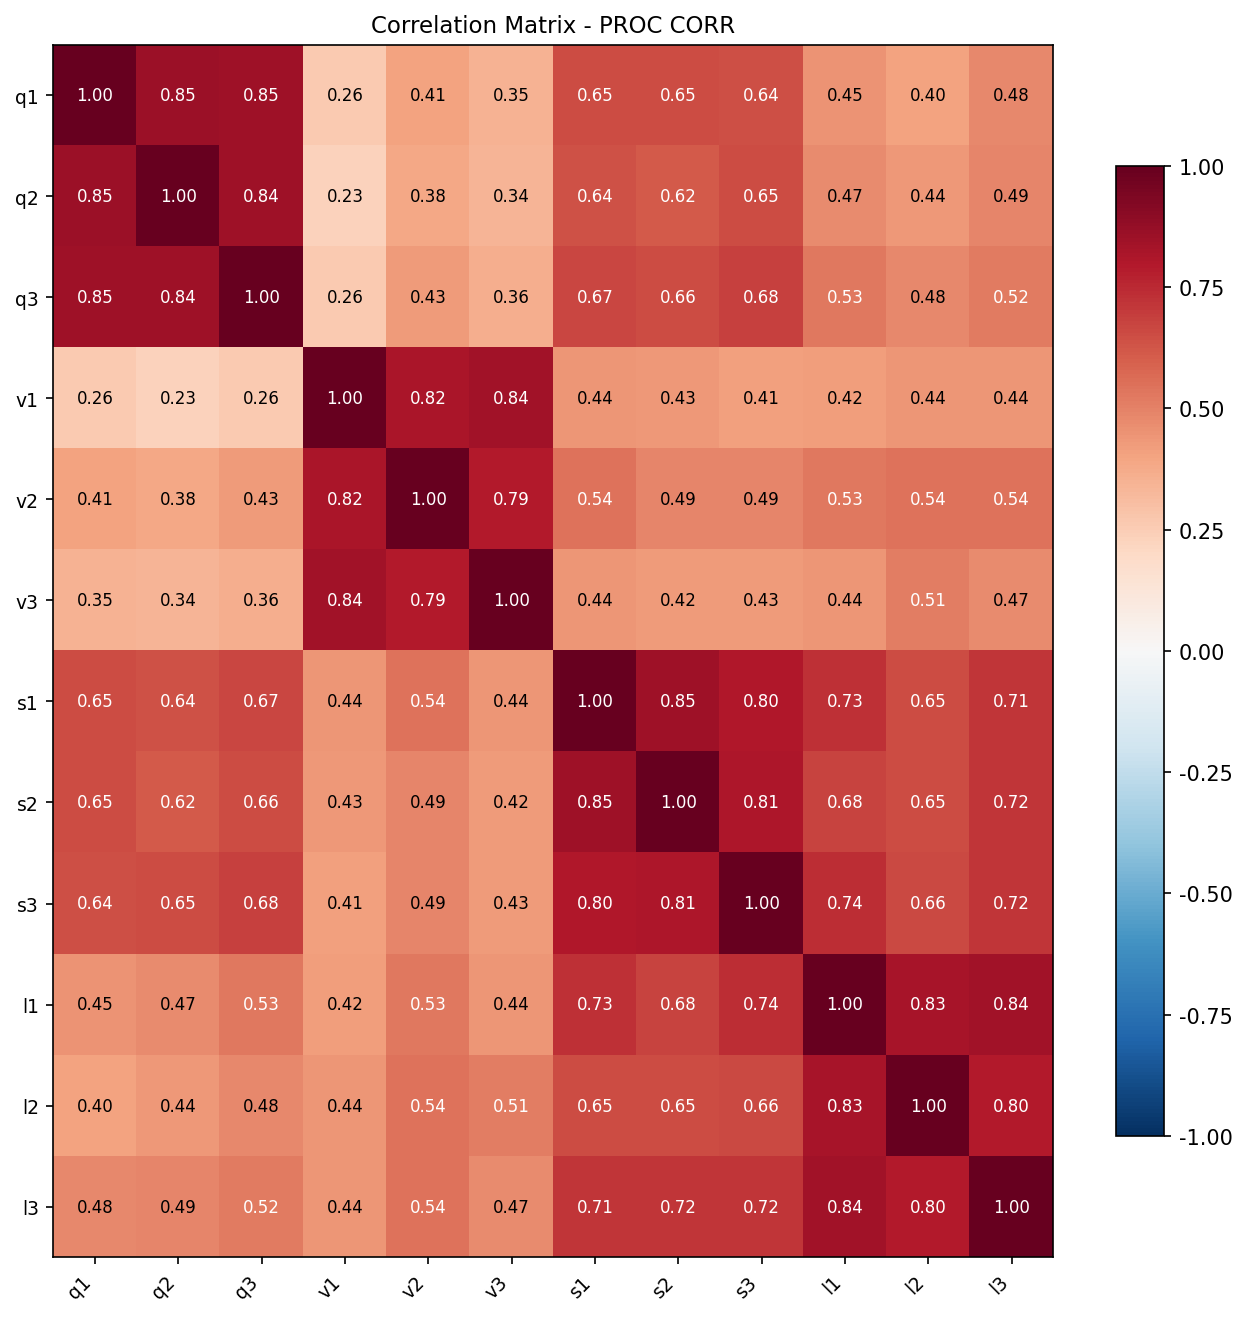

In [2]:
TITLE 'Περιγραφικά Στατιστικά Δεικτών Έρευνας';
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=survey n mean std MIN MAX maxdec=2;
   ΜΕΤΑΒΛΗΤΗ q1-q3 v1-v3 s1-s3 l1-l3;
   ΕΤΙΚΕΤΑ q1='Ποιότητα υπηρεσίας 1' q2='Ποιότητα υπηρεσίας 2' q3='Ποιότητα υπηρεσίας 3'
         v1='Αξία 1' v2='Αξία 2' v3='Αξία 3'
         s1='Ικανοποίηση 1' s2='Ικανοποίηση 2' s3='Ικανοποίηση 3'
         l1='Αφοσίωση 1' l2='Αφοσίωση 2' l3='Αφοσίωση 3';
ΕΚΤΕΛΕΣΗ;

TITLE 'Πίνακας Συσχετίσεων Δεικτών';
ΔΙΑΔΙΚΑΣΙΑ CORR ΔΕΔΟΜΕΝΑ=survey nosimple noprob;
   ΜΕΤΑΒΛΗΤΗ q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
ΕΚΤΕΛΕΣΗ;

## Βήμα 3 — Προσαρμογή του πλήρους SEM

Η προδιαγραφή `LINEQS` έχει δύο επίπεδα:

**Εξισώσεις μέτρησης** — κάθε παρατηρούμενο στοιχείο ισούται με μια φόρτιση επί τον λανθάνοντα παράγοντά του συν έναν μοναδικό όρο σφάλματος (`e1`–`e12`). Καθορίζουμε την πρώτη φόρτιση κάθε κατασκευάσματος σε `1.0` για να ορίσουμε την κλίμακα του λανθάνοντος· οι υπόλοιπες φορτίσεις είναι ελεύθερες παράμετροι (ονομάζονται `lq2`, `ls3`, ... ώστε να εμφανίζονται με το όνομά τους στην έξοδο). Κάθε όρος σφάλματος δηλώνεται στη δήλωση `variance`.

**Δομικές εξισώσεις** — το `Satis` παλινδρομείται στα `ServQual` και `Value`· το `Loyal` παλινδρομείται στα `Satis` και `Value` (μια μικρή άμεση διαδρομή). Κάθε ενδογενές λανθάνον φέρει τον δικό του όρο διαταραχής (`d1` για την ικανοποίηση, `d2` για την πιστότητα). Η ονομασία των δομικών συντελεστών (`b_sat_sq`, `b_loy_sat`, ...) διευκολύνει την ανάγνωσή τους από τον πίνακα εκτιμήσεων.

Η δήλωση `variance` δηλώνει τις δώδεκα διακυμάνσεις σφάλματος μέτρησης, τις δύο δομικές διαταραχές, και τις δύο διακυμάνσεις των εξωγενών λανθανόντων· το `cov ServQual Value` επιτρέπει στους δύο παράγοντες να συσχετίζονται. Το `method=ml` ζητά εκτίμηση μέγιστης πιθανοφάνειας (maximum-likelihood). Η έξοδος αναφέρει τη σύνοψη προσαρμογής (chi-square, RMSEA, CFI, TLI) και τον πλήρη πίνακα εκτιμήσεων παραμέτρων με τυπικά σφάλματα και τιμές t.

In [3]:
TITLE 'Δομικό Μοντέλο Εξισώσεων (SEM) Ικανοποίησης-Αφοσίωσης';
ΔΙΑΔΙΚΑΣΙΑ calis ΔΕΔΟΜΕΝΑ=survey METHOD=ml toteff;
   lineqs
      /* --- Measurement model --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Structural model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
ΕΚΤΕΛΕΣΗ;

                                 Δομικό Μοντέλο Εξισώσεων (SEM) Ικανοποίησης-Αφοσίωσης                                  


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5


NOTE: Option TITLE changed to Δομικό Μοντέλο Εξισώσεων (SEM) Ικανοποίησης-Αφοσίωσης.
NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Βήμα 4 — Οπτικοποίηση των δομικών διαδρομών

Οι τέσσερις δομικοί συντελεστές που εκτιμήθηκαν παραπάνω είναι η καρδιά του μοντέλου. Τους απεικονίζουμε δίπλα-δίπλα ώστε τα σχετικά μεγέθη — και η κυριαρχία της διαδρομής ικανοποίηση → πιστότητα — να είναι αμέσως ορατά. Οι τιμές που απεικονίζονται είναι οι εκτιμήσεις μέγιστης πιθανοφάνειας που διαβάζονται απευθείας από τον πίνακα παραμέτρων στο Βήμα 3.

                                 Δομικό Μοντέλο Εξισώσεων (SEM) Ικανοποίησης-Αφοσίωσης                                  




NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


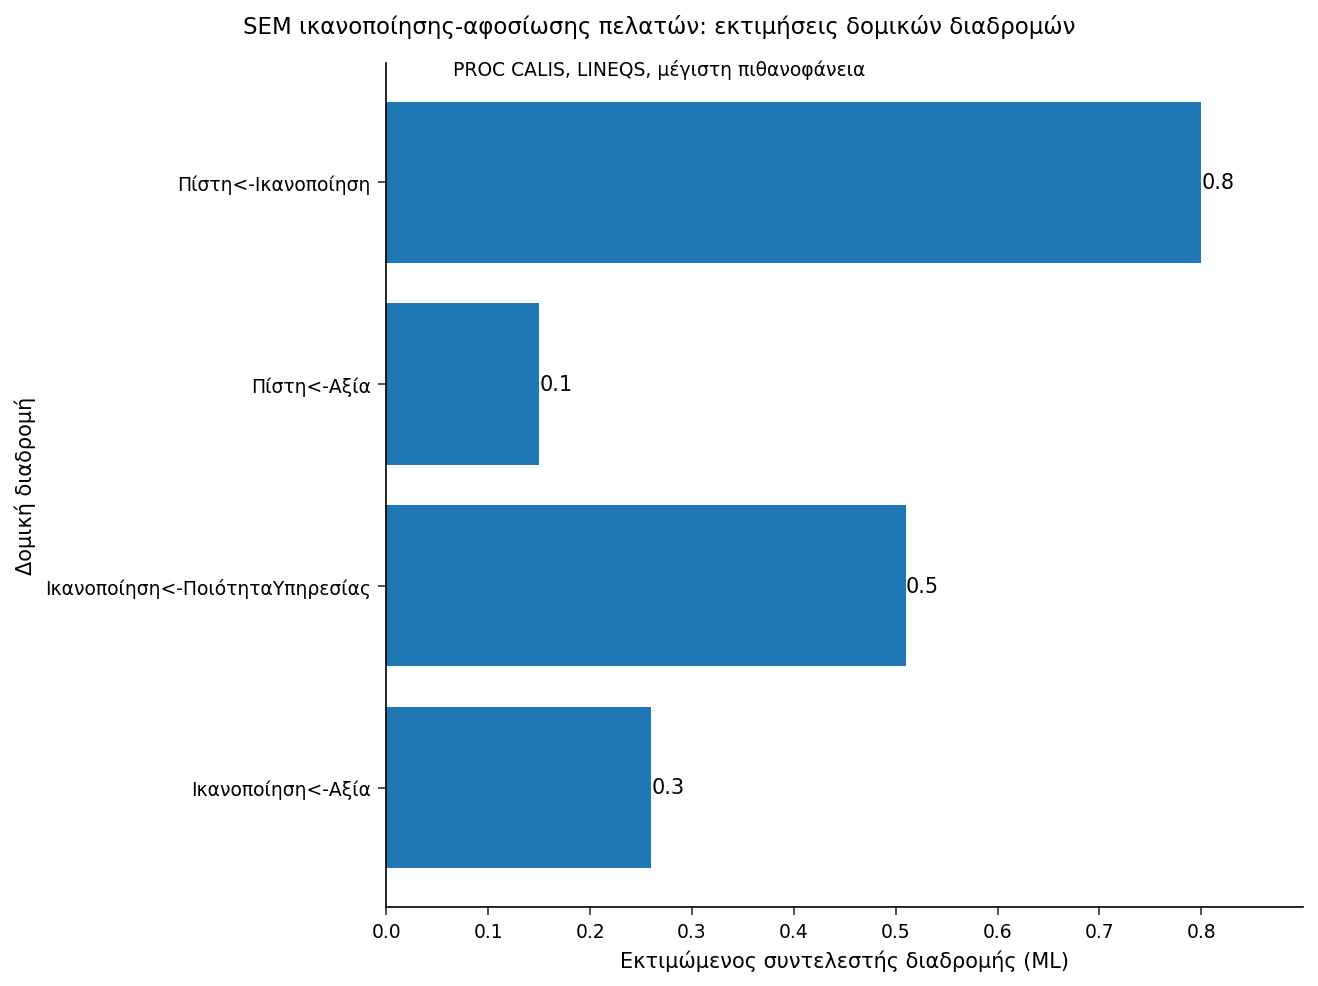

In [4]:
/* Structural path estimates from the PROC CALIS fit above */
ΔΕΔΟΜΕΝΑ paths;
   LENGTH path $60;
   ΕΙΣΟΔΟΣ path $ coef;
   DATALINES;
Πίστη<-Ικανοποίηση 0.80
Ικανοποίηση<-ΠοιότηταΥπηρεσίας 0.51
Ικανοποίηση<-Αξία 0.26
Πίστη<-Αξία 0.15
;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS ΕΤΙΚΕΤΑ="Εκτιμώμενος συντελεστής διαδρομής (ML)" MIN=0 MAX=0.9;
   YAXIS ΕΤΙΚΕΤΑ="Δομική διαδρομή" discreteorder=ΔΕΔΟΜΕΝΑ;
   TITLE  "SEM ικανοποίησης-αφοσίωσης πελατών: εκτιμήσεις δομικών διαδρομών";
   title2 "PROC CALIS, LINEQS, μέγιστη πιθανοφάνεια";
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

**Μοντέλο μέτρησης.** Κάθε ελευθερωμένη φόρτιση είναι μεγάλη και ιδιαίτερα σημαντική (όλες t > 13, p < 0.0001): τα `q2`/`q3` φορτώνουν ~0.91 στο ServQual, τα `v2`/`v3` φορτώνουν ~0.99 και 0.84 στο Value, τα `s2`/`s3` φορτώνουν ~1.03 και 0.90 στο Satis, και τα `l2`/`l3` φορτώνουν ~0.88 και 0.82 στο Loyal. Οι διακυμάνσεις σφάλματος είναι μέτριες σε σχέση με τις διακυμάνσεις των δεικτών, οπότε κάθε τριμελής συστοιχία στοιχείων μετρά καθαρά το κατασκεύασμα που προορίζεται — ο έλεγχος εγκυρότητας που δικαιολογεί την αντιμετώπιση των στοιχείων ως υποκατάστατων των λανθανόντων κατασκευασμάτων.

**Δομικό μοντέλο.** Οι εκτιμώμενες διαδρομές απαντούν άμεσα στο επιχειρηματικό ερώτημα:
- Η **ικανοποίηση** οδηγείται περισσότερο από την **ποιότητα υπηρεσίας** (`b_sat_sq` = 0.51, t = 7.99) παρά από την **αντιλαμβανόμενη αξία** (`b_sat_val` = 0.26, t = 3.86). Η επένδυση στην ποιότητα υπηρεσίας μετακινεί την ικανοποίηση περίπου διπλάσια ανά μονάδα.
- Η **πιστότητα** κυριαρχείται από την **ικανοποίηση** (`b_loy_sat` = 0.80, t = 8.54) με μόνο μια μικρή *άμεση* διαδρομή αξίας (`b_loy_val` = 0.15, t = 2.02) που παρακάμπτει την ικανοποίηση.
- Οι δύο παράγοντες συσχετίζονται θετικά (συνδιακύμανση ServQual–Value 0.44, t = 3.36), όπως αναμένεται όταν και οι δύο αντανακλούν μια κοινή υποκείμενη εμπειρία.

**Αποσύνθεση επιδράσεων.** Ο πολλαπλασιασμός κατά μήκος της αλυσίδας διαχωρίζει το έμμεσο (μέσω-ικανοποίησης) κανάλι από το άμεσο:
- **Αξία → Πιστότητα:** έμμεση = 0.26 × 0.80 = **0.21**, άμεση = **0.15**, συνολική ≈ **0.36**. Το μεγαλύτερο μέρος της έλξης της αξίας προς την πιστότητα ρέει μέσω της ικανοποίησης.
- **Ποιότητα υπηρεσίας → Πιστότητα:** δεν υπάρχει άμεση διαδρομή, οπότε ολόκληρη η επίδραση είναι έμμεση = 0.51 × 0.80 = **0.41** — ο μοναδικός μεγαλύτερος παράγοντας της πιστότητας στο μοντέλο.

Αυτό ποσοτικοποιεί τον στρατηγικό ισχυρισμό: *η βελτίωση της ικανοποίησης είναι ο πρωταρχικός μοχλός για την πιστότητα*, και η ποιότητα υπηρεσίας είναι ο πιο αποδοτικός τρόπος για να αυξηθεί η ικανοποίηση εξαρχής.

**Προσαρμογή.** Το μοντέλο αναπαράγει καλά τις παρατηρούμενες συνδιακυμάνσεις — chi-square = 50.81 (df = 49, p = 0.40, μια μη σημαντική τιμή που υποδεικνύει καμία ανιχνεύσιμη κακή προσαρμογή), RMSEA = 0.019 (πολύ κάτω από το όριο "στενής προσαρμογής" του 0.05), CFI = 0.999 και TLI = 0.998 (και τα δύο πάνω από το σημείο αναφοράς 0.95). Η υποτιθέμενη αλυσίδα όπου η ικανοποίηση διαμεσολαβεί την πιστότητα είναι πλήρως συνεπής με τα δεδομένα.

Εν συντομία: ο λιανοπωλητής μπορεί να διαβάσει πόση πιστότητα *κατασκευάζεται μέσω της ικανοποίησης*, και ποιος παράγοντας — ποιότητα υπηρεσίας ή αξία — αυξάνει πιο αποδοτικά την ικανοποίηση εξαρχής.